In [1]:
%load_ext autoreload
%autoreload 2

# Analyzing density functional theory calculations of ion binding

This notebook contains the code required to reproduce the analysis for the density functional theory (DFT) calculations of alkali and alkali earth ions binding in the composite building units (CBUs) of the zeolites studied in the paper associated with this repository.

## Setup

In [ ]:
from collections import Counter

# import analysis tools
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
import numpy as np
from rdkit import Chem
import seaborn as sns

from scipy.special import softmax
from pymatgen.core import Molecule

PERIODICTABLE = Chem.GetPeriodicTable()

In [ ]:
plt.rcParams["figure.dpi"] = 200

# font used in publication figures; if this is not available, matplotlib will use the default font
mpl.rcParams["font.family"] = "Arial"

In [4]:
HARTREE_TO_KJ_MOL = 2625.5002  # kJ/mol
K_BOLTZMANN = 0.008314463  # kJ/mol/K

# set an approximate synthesis temperature for analyzing binding energies
SYNTH_TEMP = 400  # K

The ionic radii of alkali and alkali earth ions below are in pm from RD Shannon, _Acta Cryst. A_ (1976), **32**, 751-767.
The  ionic radius of TMA<sup>+</sup> is from Aue, Webb, and Bowers, _JACS_ (1976), **98**, 318-329 (Table II).

In [5]:
IONIC_RADII = {
    "Li+": 90,
    "Na+": 116,
    "K+": 152,
    "Rb+": 166,
    "Cs+": 167,
    "Be+2": 59,
    "Mg+2": 86,
    "Ca+2": 114,
    "Sr+2": 132,
    "Ba+2": 149,
    "C4H12N+": 322,
}

The solvation energies below are in kJ/mol at 298.15 K from Marcus, _Biophys. Chem._ (1994), 111-127 unless otherwise noted (see also Schmid, Miah, and Sapunov, PCCP (2000)).

In [6]:
SOLVATION_ENERGIES = {
    "Li+": -475,
    "Na+": -365,
    "K+": -295,
    "Rb+": -275,
    "Cs+": -250,
    "Be+2": -2395,
    "Mg+2": -1830,
    "Ca+2": -1505,
    "Sr+2": -1380,
    "Ba+2": -1250,
    "C4H12N+": -160,
}

In [ ]:
def get_aluminum_dists(cbu_id: int) -> float:
    """Get the distance between the two Al atoms for such structures

    Args:
        cbu_id (int): the ID number of the structure of the CBU with two Al atoms

    Returns:
        float: the distance between the two Al atoms in Angstroms
    """
    gg = Molecule.from_file(f"structures/{cbu_id}.xyz")
    al_indices = [i for i, atom in enumerate(gg) if atom.species_string == "Al"]
    if len(al_indices) != 2:
        return None

    return gg.get_distance(*al_indices)

## Organize the calculation outputs

### Grab the data

In [8]:
ion_elems = [
    "Li",
    "Na",
    "K",
    "Rb",
    "Cs",
    "Be",
    "Mg",
    "Ca",
    "Sr",
    "Ba",
    "C4",  # C4 is a placeholder for TMA+
]

In [9]:
df = pd.read_csv("data/all_ion_binding_energies.csv", index_col=0)
df.dropna(inplace=True)

We made an old bookkeeping error in earlier analysis, so some of our original work used _ufi_ as the name for the _wbc_ CBU. This issue is fixed below.

In [10]:
# replace "ufi" with "wbc" in the cbu_nickname column
df.loc[df["cbu_nickname"] == "ufi", "cbu_nickname"] = "wbc"

In [11]:
kdf = df.loc[df["cbu_nickname"] == "K222"]

In [12]:
kdf.to_csv("data/k222_binding_data.csv")

The cell below organizes the experimental synthesis outcomes in a readily accessible format so that they can be compared to the binding energy results more easily.

In [13]:
# wbc and ufi are the same but I never remember wbc
synthesis = {
    "KFI": {"cbus": ["lta", "pau", "d6r"], "ions": ["K", "Sr"]},
    "RHO": {"cbus": ["lta", "d8r"], "ions": ["Na", "Cs"]},
    "LTA": {"cbus": ["lta", "sod", "d4r"], "ions": ["Na", "TMA"]},
    "UFI": {"cbus": ["lta", "ufi", "wbc", "rth", "d4r"], "ions": ["Na", "TMA"]},
}

The recipes for LTA and UFI use approximately the same amount of silica, alumina, and TMA; however, the UFI synthesis used slightly more Na in the synthesis gel. Both required a seed crystal to produce the final product.

All materials have an _lta_ cage, which contains 4-MR, 6-MR, and 8-MR. It's likely that Na in the RHO synthesis helps stabilize 6-MR in the _lta_ cage and is not assisting with the stabilization of 8-MR at all (Na seems to have a history of low selectivity for zeolite frameworks).

The _pau_ cage is ostensibly the largest of the CBUs in this dataset, but it's not stabilized by the Cs<sup>+</sup> ion; both K and Sr are smaller. One possible explanation is that the solvation shell for Sr<sup>2+</sup> is simply much larger than the solvation shell for any of the monovalent ions (and more flexible). As such, it may end up stabilizing the _pau_ cage even though its ionic radius is smaller than Cs<sup>+</sup>.

In [14]:
syn_ion_pairs = {
    "pau": ["K", "Sr"],
    "d6r": ["K", "Sr"],
    "d8r": ["Cs"],
    "sod": ["Na", "TMA"],
    "d4r": ["Na", "TMA"],
    "ufi": ["Na", "TMA"],
    "wbc": ["Na", "TMA"],
    "rth": ["Na", "TMA"],
}

### Split into mono- and divalent ion dataframes

In [15]:
ion_list = df["bare_ion_formula"].unique().tolist()
cbu_list = df["cbu_nickname"].unique().tolist()
ion_list

['Li+', 'Na+', 'K+', 'Rb+', 'Cs+', 'Sr+2', 'Ba+2']

In [16]:
cbu_list

['K222', 'rth', 'd6r', 'pau', 'wbc', 'd8r', 'sod', 'd4r']

In [17]:
mono_df = df[
    df["bare_ion_formula"].isin(["Na+", "K+", "Rb+", "Cs+", "C4H12N+"])
].sort_values(by=["ion_binding_energy"])
di_df = df[df["bare_ion_formula"].isin(["Sr+2", "Ba+2"])].sort_values(
    by=["ion_binding_energy"]
)

In [18]:
di_df["aluminum_dist"] = di_df.index.to_series().apply(get_aluminum_dists)

In [19]:
di_df.head()

,docked_cbu_energy,cbu_nickname,bare_ion_formula,bare_ion_radius,ion_valence,empty_cbu_geom_id,empty_cbu_energy,solvated_cbu_energy,bare_ion_energy,solvated_ion_energy,solvated_dock_geom_id,solvated_dock_energy,rel_vac_docked_energy,rel_sol_docked_energy,ion_binding_energy,solvated_ion_binding_energy,bare_solvated_binding_diff,sol_sol_ion_binding_energy,aluminum_dist
docked_cbu_geom_id,,,,,,,,,,,,,,,,,,,
481214975,-7591.211712,d8r,Sr+2,132,divalent,448063925,-7560.347822,-7560.774934,-30.100213,-30.519776,574851810.0,-7591.357581,34.508155,87.636221,-2005.032610,-903.471455,1101.561155,-165.069426,3.095227
463865377,-5677.546454,d6r,Sr+2,132,divalent,448062840,-5646.720551,-5647.114920,-30.100213,-30.519776,573604211.0,-5677.653976,99.254401,63.358377,-1905.298286,-803.737131,1101.561155,-50.622206,3.080060
463867383,-7591.224856,d8r,Sr+2,132,divalent,448063971,-7560.402781,-7560.795759,-30.100213,-30.519776,574825783.0,-7591.390960,0.000000,0.000000,-1895.247380,-793.686226,1101.561155,-198.030460,5.728688
481215179,-7591.205228,d8r,Sr+2,132,divalent,448063972,-7560.384534,-7560.792081,-30.100213,-30.519776,574848483.0,-7591.352497,51.532977,100.984205,-1891.619928,-790.058773,1101.561155,-106.702753,4.374841
463250959,-5677.533918,d6r,Sr+2,132,divalent,448062857,-5646.720365,-5647.114568,-30.100213,-30.519776,573573092.0,-5677.639335,132.170121,101.800229,-1872.871227,-771.310072,1101.561155,-13.104615,3.090216


In [20]:
cbus = Counter(di_df["cbu_nickname"])
cbus

Counter({'wbc': 83,
         'pau': 67,
         'sod': 23,
         'rth': 22,
         'd8r': 16,
         'd6r': 14,
         'd4r': 6,
         'K222': 2})

## Plot the data

### Violin plots for BE vs. subunit for each ion

In [21]:
desired_mono_order = ["Na+", "K+", "Rb+", "Cs+"]  # , "C4H12N+"]
desired_di_order = ["Sr+2", "Ba+2"]
cbu_order = ["d4r", "rth", "d6r", "wbc", "d8r", "pau", "sod", "K222"]
slim_cbu_order = ["rth", "d6r", "wbc", "d8r", "pau", "sod", "K222"]
mono_labels = [
    "Na$^{\mathdefault{+}}$",
    "K$^{\mathdefault{+}}$",
    "Rb$^{\mathdefault{+}}$",
    "Cs$^{\mathdefault{+}}$",
]
di_labels = ["Sr$^{\mathdefault{2+}}$", "Ba$^{\mathdefault{2+}}$"]
desired_all_order = desired_mono_order + desired_di_order
all_labels = mono_labels + di_labels

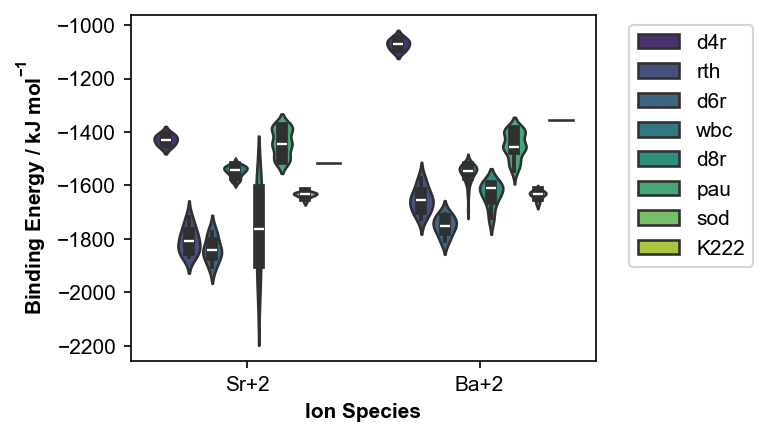

In [62]:
# make a violin plot of the binding energies for each ion with cbu on the x-axis

fig, ax = plt.subplots(figsize=(4, 3), dpi=150)

# sns.violinplot(x='bare_ion_formula', y='ion_binding_energy', data=mono_df, ax=axes[0], hue='cbu_nickname', palette='viridis')
sns.violinplot(
    x="bare_ion_formula",
    y="ion_binding_energy",
    data=di_df,
    ax=ax,
    hue="cbu_nickname",
    palette="viridis",
    order=desired_di_order,
    hue_order=cbu_order,
)

# use the same label for the x axis for both plots
ax.set_xlabel("Ion Species", fontweight="bold")

ax.set_ylabel("Binding Energy / kJ mol$\mathdefault{^{-1}}$", fontweight="bold")
ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1))

fig.savefig("figures/vacuum_divalent_binding_energies_violin.svg", dpi=300)

### Binding energy heatmaps

In [23]:
mono_df.columns

Index(['docked_cbu_energy', 'cbu_nickname', 'bare_ion_formula',
       'bare_ion_radius', 'ion_valence', 'empty_cbu_geom_id',
       'empty_cbu_energy', 'solvated_cbu_energy', 'bare_ion_energy',
       'solvated_ion_energy', 'solvated_dock_geom_id', 'solvated_dock_energy',
       'rel_vac_docked_energy', 'rel_sol_docked_energy', 'ion_binding_energy',
       'solvated_ion_binding_energy', 'bare_solvated_binding_diff',
       'sol_sol_ion_binding_energy'],
      dtype='object')

In [24]:
all_vac_weighted_bindings = {"cbu": cbu_order}
all_sol_weighted_bindings = {"cbu": cbu_order}
for ion in desired_all_order:
    all_vac_weighted_bindings[ion] = []
    all_sol_weighted_bindings[ion] = []
    for cbu in cbu_order:
        bdf = df[(df["bare_ion_formula"] == ion) & (df["cbu_nickname"] == cbu)]
        all_vac_weighted_bindings[ion].append(
            (
                bdf["ion_binding_energy"]
                * softmax(
                    -bdf["rel_vac_docked_energy"] / (K_BOLTZMANN * SYNTH_TEMP), axis=0
                )
            ).sum()
        )
        all_sol_weighted_bindings[ion].append(
            (
                bdf["sol_sol_ion_binding_energy"]
                * softmax(
                    -bdf["rel_sol_docked_energy"] / (K_BOLTZMANN * SYNTH_TEMP), axis=0
                )
            ).sum()
        )

In [25]:
all_vac_min_bindings = {"cbu": cbu_order}
all_sol_min_bindings = {"cbu": cbu_order}
for ion in desired_all_order:
    all_vac_min_bindings[ion] = []
    all_sol_min_bindings[ion] = []
    for cbu in cbu_order:
        bdf = df[(df["bare_ion_formula"] == ion) & (df["cbu_nickname"] == cbu)]
        all_vac_min_bindings[ion].append(
            bdf.loc[bdf["rel_vac_docked_energy"] == 0.0]["ion_binding_energy"].iloc[0]
        )
        all_sol_min_bindings[ion].append(
            bdf.loc[bdf["rel_sol_docked_energy"] == 0.0][
                "sol_sol_ion_binding_energy"
            ].iloc[0]
        )

In [26]:
mono_vac_weighted_bindings = {"cbu": cbu_order}
mono_sol_weighted_bindings = {"cbu": cbu_order}
for ion in desired_mono_order:
    mono_vac_weighted_bindings[ion] = []
    mono_sol_weighted_bindings[ion] = []
    for cbu in cbu_order:
        bdf = mono_df[
            (mono_df["bare_ion_formula"] == ion) & (mono_df["cbu_nickname"] == cbu)
        ]
        mono_vac_weighted_bindings[ion].append(
            (
                bdf["ion_binding_energy"]
                * softmax(
                    -bdf["rel_vac_docked_energy"] / (K_BOLTZMANN * SYNTH_TEMP), axis=0
                )
            ).sum()
        )
        mono_sol_weighted_bindings[ion].append(
            (
                bdf["sol_sol_ion_binding_energy"]
                * softmax(
                    -bdf["rel_sol_docked_energy"] / (K_BOLTZMANN * SYNTH_TEMP), axis=0
                )
            ).sum()
        )

In [27]:
di_vac_weighted_bindings = {"cbu": cbu_order}
di_sol_weighted_bindings = {"cbu": cbu_order}
for ion in desired_di_order:
    di_vac_weighted_bindings[ion] = []
    di_sol_weighted_bindings[ion] = []
    for cbu in cbu_order:
        bdf = di_df[(di_df["bare_ion_formula"] == ion) & (di_df["cbu_nickname"] == cbu)]
        di_vac_weighted_bindings[ion].append(
            (
                bdf["ion_binding_energy"]
                * softmax(
                    -bdf["rel_vac_docked_energy"] / (K_BOLTZMANN * SYNTH_TEMP), axis=0
                )
            ).sum()
        )
        di_sol_weighted_bindings[ion].append(
            (
                bdf["sol_sol_ion_binding_energy"]
                * softmax(
                    -bdf["rel_sol_docked_energy"] / (K_BOLTZMANN * SYNTH_TEMP), axis=0
                )
            ).sum()
        )

In [28]:
mono_vac_binding = pd.DataFrame(mono_vac_weighted_bindings).set_index("cbu")
mono_sol_binding = pd.DataFrame(mono_sol_weighted_bindings).set_index("cbu")
di_vac_binding = pd.DataFrame(di_vac_weighted_bindings).set_index("cbu")
di_sol_binding = pd.DataFrame(di_sol_weighted_bindings).set_index("cbu")
all_vac_binding = pd.DataFrame(all_vac_weighted_bindings).set_index("cbu")
all_sol_binding = pd.DataFrame(all_sol_weighted_bindings).set_index("cbu")
all_vac_min_binding = pd.DataFrame(all_vac_min_bindings).set_index("cbu")
all_sol_min_binding = pd.DataFrame(all_sol_min_bindings).set_index("cbu")
all_sol_binding

,Na+,K+,Rb+,Cs+,Sr+2,Ba+2
cbu,,,,,,
d4r,219.382523,410.898090,646.839349,984.855792,416.816366,682.025387
rth,13.451842,62.527370,141.835617,255.137241,-2.155413,52.640082
d6r,-85.025363,8.414233,27.274880,54.884021,-51.860650,-23.938547
wbc,-68.564261,-48.532061,-50.240368,-83.746781,-81.281150,-98.054283
d8r,-38.159246,-24.392592,-44.650803,-101.451186,-198.027344,-214.413823
pau,-50.167198,-72.703023,-70.286487,-78.948455,-76.380802,-101.284559
sod,-76.678682,-53.322261,-60.446260,-106.267193,-81.718561,-87.702952
K222,-156.351402,-149.446510,-138.170526,-138.931131,-413.087527,-330.744027


In [29]:
all_sol_min_binding

,Na+,K+,Rb+,Cs+,Sr+2,Ba+2
cbu,,,,,,
d4r,219.382523,410.898090,646.839349,984.855792,417.392604,682.729779
rth,12.923498,62.592586,141.723259,254.756254,-0.096426,53.142823
d6r,-85.025363,8.414233,27.274880,54.884021,-51.968547,-23.752709
wbc,-69.546785,-50.156967,-51.689320,-85.390302,-79.500520,-103.840040
d8r,-38.159246,-24.392592,-44.650803,-101.451186,-198.030460,-214.415563
pau,-50.736216,-73.354363,-70.926126,-79.675322,-77.889394,-102.833142
sod,-76.678682,-53.322261,-60.446260,-106.267193,-82.431453,-89.980150
K222,-156.351402,-149.446510,-138.170526,-138.931131,-413.087527,-330.744027


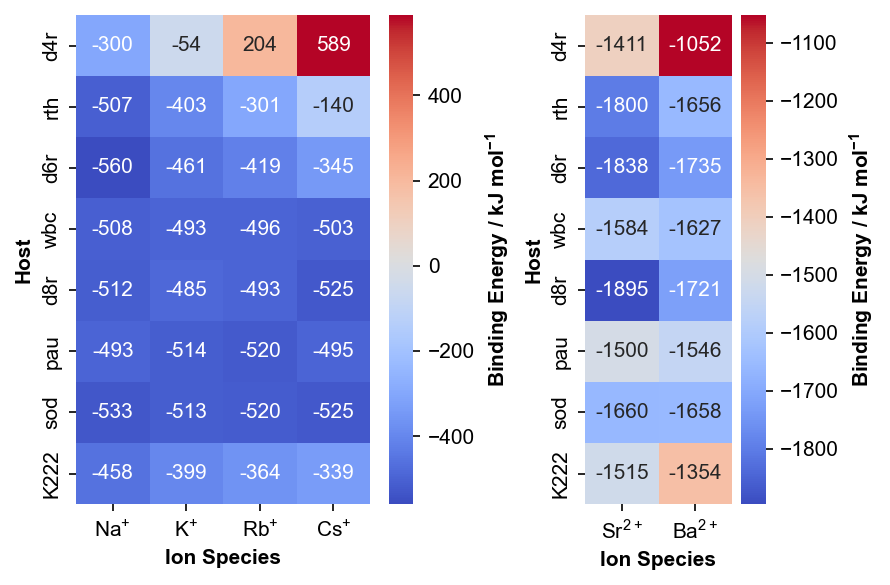

In [63]:
# make a seaborn heat map of the binding energies for each ion with cbu on the x-axis and ion on the y-axis

# get fig and axes where the first axis is twice as wide as the second
fig, axes = plt.subplots(1, 2, figsize=(6, 4), width_ratios=[2, 1], dpi=150)

sns.heatmap(
    data=mono_vac_binding,
    ax=axes[0],
    cmap="coolwarm",
    annot=True,
    fmt=".0f",
    xticklabels=mono_labels,
    cbar_kws={"label": "Binding Energy / kJ mol$^{\mathdefault{-1}}$"},
)
sns.heatmap(
    data=di_vac_binding,
    ax=axes[1],
    cmap="coolwarm",
    annot=True,
    fmt=".0f",
    xticklabels=di_labels,
    cbar_kws={"label": "Binding Energy / kJ mol$^{\mathdefault{-1}}$"},
)
# axes[0].set_title("Monovalent Ions", fontweight="bold")
# axes[1].set_title("Divalent Ions", fontweight="bold")
for ax in axes:
    ax.set_xlabel("Ion Species", fontweight="bold")
    ax.set_ylabel("Host", fontweight="bold")

    # set the colorbar label to have bold font and rotate 180 degrees
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.label.set_fontweight("bold")


fig.tight_layout()
fig.savefig("figures/vacuum_binding_energies_all_heatmap.svg", dpi=300)

In [90]:
def shifted_cmap(cmap, midpoint=0.5, name="shiftedcmap"):
    """
    Return a new colormap whose original center (0.5) is moved to `midpoint`.
    """
    x_old = np.linspace(0, 1, 257)

    # Piecewise remapping:
    # old [0, 0.5]  -> new [0, midpoint]
    # old [0.5, 1]  -> new [midpoint, 1]
    x_new = np.hstack(
        [np.linspace(0, midpoint, 128, endpoint=False), np.linspace(midpoint, 1, 129)]
    )

    colors = cmap(x_old)
    new_cmap = mcolors.LinearSegmentedColormap.from_list(name, list(zip(x_new, colors)))
    return new_cmap

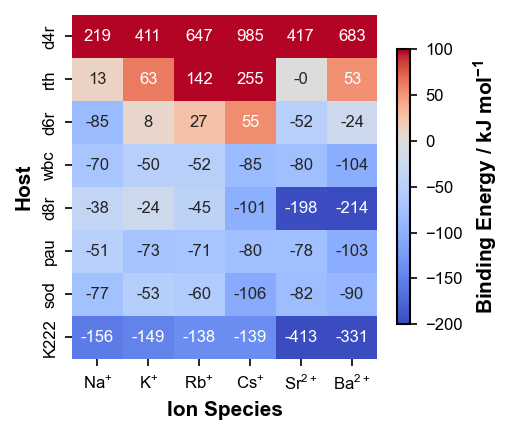

In [ ]:
# make a seaborn heat map of the binding energies for each ion with cbu on the x-axis and ion on the y-axis

vmin = -200
vmax = 100
midpoint = (0 - vmin) / (vmax - vmin)  # = 2/3

cmap = shifted_cmap(plt.get_cmap("coolwarm"), midpoint=midpoint)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

# get fig and axes where the first axis is twice as wide as the second
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3), dpi=150)

hm = sns.heatmap(
    data=all_sol_min_binding,
    ax=ax,
    cmap=cmap,
    # cmap=cmap,
    annot=True,
    fmt=".0f",
    norm=norm,
    xticklabels=all_labels,
    cbar_kws={"label": "Binding Energy / kJ mol$^{\mathdefault{-1}}$", "shrink": 0.8},
    annot_kws={"size": 8},
)
# fig.suptitle("Ion-CBU Binding with Implicit Solvent", fontweight="bold", fontstyle="italic")
ax.set_xlabel("Ion Species", fontweight="bold", fontsize=10)
ax.set_ylabel("Host", fontweight="bold", fontsize=10)
ax.set_xticklabels(
    all_labels,
    fontsize=8,
)
ax.set_yticklabels(
    all_sol_min_binding.index,
    fontsize=8,
)
# set the colorbar label to have bold font and rotate 180 degrees
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_fontweight("bold")
cbar.ax.yaxis.label.set_size(10)

# Soon's suggestion: set the colorbar ticks to be every 50 kJ/mol from -200 to 100
cbar.set_ticks(np.arange(-200, 101, 50))
cbar.ax.tick_params(labelsize=8)
# add a black border around the colorbar
cbar.outline.set_edgecolor("black")
cbar.outline.set_linewidth(1)

fig.tight_layout()
fig.savefig("figures/sol_binding_energies_all_heatmap.svg", dpi=300)

In [32]:
df.columns

Index(['docked_cbu_energy', 'cbu_nickname', 'bare_ion_formula',
       'bare_ion_radius', 'ion_valence', 'empty_cbu_geom_id',
       'empty_cbu_energy', 'solvated_cbu_energy', 'bare_ion_energy',
       'solvated_ion_energy', 'solvated_dock_geom_id', 'solvated_dock_energy',
       'rel_vac_docked_energy', 'rel_sol_docked_energy', 'ion_binding_energy',
       'solvated_ion_binding_energy', 'bare_solvated_binding_diff',
       'sol_sol_ion_binding_energy'],
      dtype='object')

In [33]:
df.loc[(df["cbu_nickname"] == "d8r") & (df["bare_ion_formula"] == "Sr+2")][
    "sol_sol_ion_binding_energy"
].describe()

count      9.000000
mean     -86.876005
std       88.963479
min     -198.030460
25%     -160.537569
50%     -106.702753
75%      -21.564441
max       42.896288
Name: sol_sol_ion_binding_energy, dtype: float64

In [34]:
df.loc[(df["cbu_nickname"] == "d8r") & (df["bare_ion_formula"] == "Ba+2")][
    "sol_sol_ion_binding_energy"
].describe()

count      7.000000
mean     -96.045729
std      100.734725
min     -214.415563
25%     -177.528605
50%     -127.157939
75%        7.829973
max        8.650662
Name: sol_sol_ion_binding_energy, dtype: float64

# compare solvation free energies of ions in literature to computed solvation energies

In [35]:
bare_df = df.reset_index()[
    [
        "bare_ion_formula",
        "bare_ion_radius",
        "ion_valence",
        "bare_ion_energy",
        "solvated_ion_energy",
    ]
].drop_duplicates()

bare_df["solvation_energy_comp"] = (
    bare_df["solvated_ion_energy"] - bare_df["bare_ion_energy"]
) * HARTREE_TO_KJ_MOL
bare_df["solvation_free_energy_expt"] = bare_df["bare_ion_formula"].apply(
    lambda x: SOLVATION_ENERGIES[x]
)
bare_df

,bare_ion_formula,bare_ion_radius,ion_valence,bare_ion_energy,solvated_ion_energy,solvation_energy_comp,solvation_free_energy_expt
0,Li+,90,monovalent,-7.289727,-7.433223,-376.750160,-475
1,Na+,116,monovalent,-162.080818,-162.195872,-302.072739,-365
2,K+,152,monovalent,-599.756603,-599.851578,-249.357523,-295
3,Rb+,166,monovalent,-23.948670,-24.034870,-226.316918,-275
4,Cs+,167,monovalent,-20.008501,-20.084648,-199.922321,-250
5,Sr+2,132,divalent,-30.100213,-30.519776,-1101.561155,-1380
6,Ba+2,149,divalent,-24.918321,-25.308147,-1023.488668,-1250


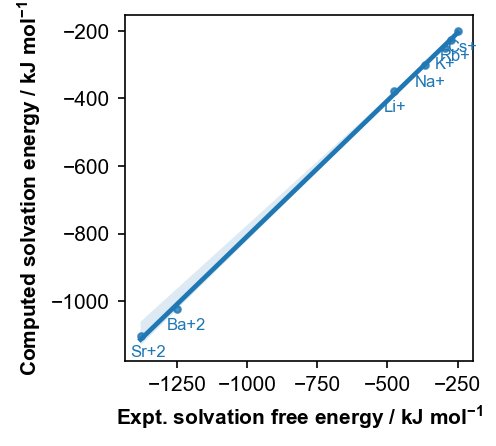

In [92]:
# make a scatter plot showing the expt solvation free energies vs. computed solvation energies
fig, ax = plt.subplots(figsize=(3, 3), dpi=150)

sns.regplot(
    x="solvation_free_energy_expt",
    y="solvation_energy_comp",
    data=bare_df,
    ax=ax,
    scatter_kws={"s": 10},
)

ax.set_xlabel(
    "Expt. solvation free energy / kJ mol$^{\mathdefault{-1}}$", fontweight="bold"
)
ax.set_ylabel(
    "Computed solvation energy / kJ mol$^{\mathdefault{-1}}$", fontweight="bold"
)
# label each point with the bare ion formula below the point
for i, row in bare_df.iterrows():
    ax.annotate(
        row["bare_ion_formula"],
        xy=(row["solvation_free_energy_expt"], row["solvation_energy_comp"]),
        xycoords="data",
        fontsize=8,
        color="C0",
        xytext=(-5, -10),
        textcoords="offset points",
    )

# plot divalent binding energies as function of aluminum distances

In [93]:
# count the number of each unique CBU in the di dataframes

di_df["cbu_nickname"].value_counts()

cbu_nickname
wbc     83
pau     67
sod     23
rth     22
d8r     16
d6r     14
d4r      6
K222     2
Name: count, dtype: int64

In [94]:
important_cbus = ["wbc", "pau", "sod", "d6r"]

less_di_df = di_df.loc[di_df["cbu_nickname"].isin(important_cbus)]

In [95]:
less_di_df.columns

Index(['docked_cbu_energy', 'cbu_nickname', 'bare_ion_formula',
       'bare_ion_radius', 'ion_valence', 'empty_cbu_geom_id',
       'empty_cbu_energy', 'solvated_cbu_energy', 'bare_ion_energy',
       'solvated_ion_energy', 'solvated_dock_geom_id', 'solvated_dock_energy',
       'rel_vac_docked_energy', 'rel_sol_docked_energy', 'ion_binding_energy',
       'solvated_ion_binding_energy', 'bare_solvated_binding_diff',
       'sol_sol_ion_binding_energy', 'aluminum_dist'],
      dtype='object')

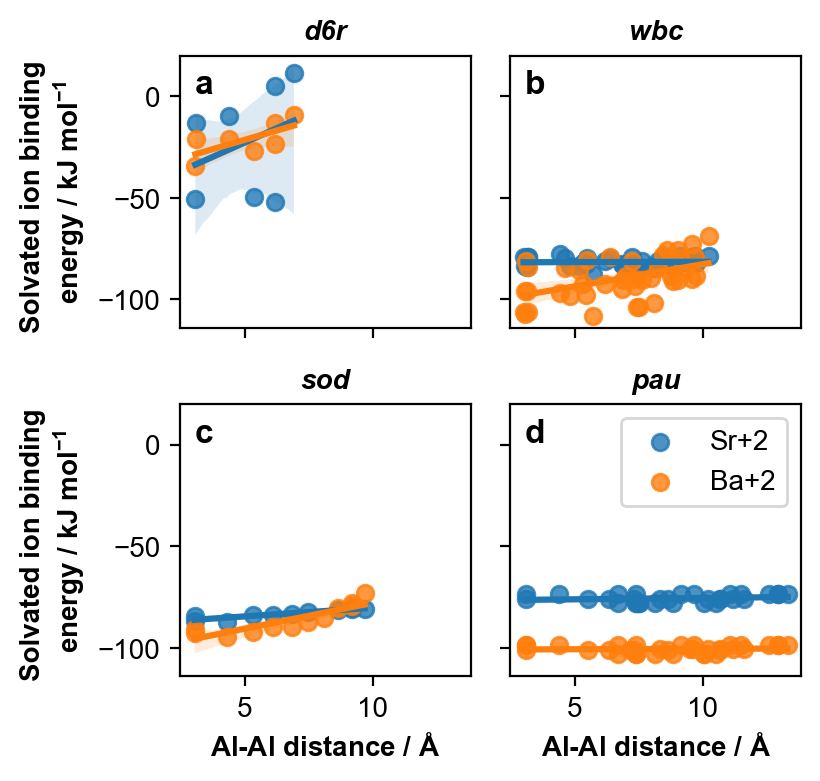

In [96]:
labels = ["a", "b", "c", "d"]
plot = sns.lmplot(
    data=less_di_df,
    x="aluminum_dist",
    y="sol_sol_ion_binding_energy",
    hue="bare_ion_formula",
    col="cbu_nickname",
    col_wrap=2,
    height=2.0,
    aspect=1.0,
    legend=False,
    facet_kws={"despine": False},
)
# sns.lmplot(data=al_calc_df, x='sum_inv_dists', y='rel_E', hue='stoichiometry', height=3, aspect=1.618, facet_kws={'despine': False})
plot.set_axis_labels(
    "Al-Al distance / $\mathdefault{\\AA}$",
    "Solvated ion binding \nenergy / kJ mol$^{\mathdefault{\minus 1}}$",
    fontweight="bold",
)
plot.set_titles("{col_name}", fontweight="bold", fontstyle="italic")

for ax in plot.axes:
    ax.annotate(
        labels.pop(0),
        (0.05, 0.95),
        xycoords="axes fraction",
        fontsize=12,
        fontweight="bold",
        verticalalignment="top",
        horizontalalignment="left",
    )

plt.legend(loc="upper right")
plot.savefig("figures/di_binding_vs_al_dist.svg", dpi=300)
plt.show()

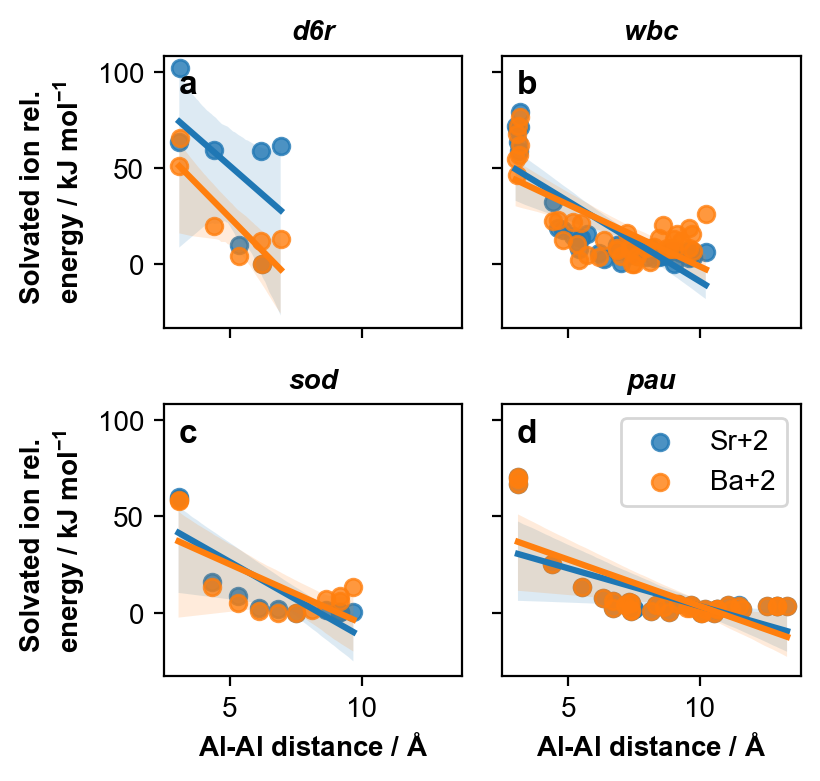

In [97]:
labels = ["a", "b", "c", "d"]
plot = sns.lmplot(
    data=less_di_df,
    x="aluminum_dist",
    y="rel_sol_docked_energy",
    hue="bare_ion_formula",
    col="cbu_nickname",
    col_wrap=2,
    height=2.0,
    aspect=1.0,
    legend=False,
    facet_kws={"despine": False},
)
# sns.lmplot(data=al_calc_df, x='sum_inv_dists', y='rel_E', hue='stoichiometry', height=3, aspect=1.618, facet_kws={'despine': False})
plot.set_axis_labels(
    "Al-Al distance / $\mathdefault{\\AA}$",
    "Solvated ion rel. \nenergy / kJ mol$^{\mathdefault{\minus 1}}$",
    fontweight="bold",
)
plot.set_titles("{col_name}", fontweight="bold", fontstyle="italic")

for ax in plot.axes:
    ax.annotate(
        labels.pop(0),
        (0.05, 0.95),
        xycoords="axes fraction",
        fontsize=12,
        fontweight="bold",
        verticalalignment="top",
        horizontalalignment="left",
    )

plt.legend(loc="upper right")
plot.savefig("figures/di_binding_vs_al_dist.svg", dpi=300)
plt.show()

In [98]:
di_df.columns

Index(['docked_cbu_energy', 'cbu_nickname', 'bare_ion_formula',
       'bare_ion_radius', 'ion_valence', 'empty_cbu_geom_id',
       'empty_cbu_energy', 'solvated_cbu_energy', 'bare_ion_energy',
       'solvated_ion_energy', 'solvated_dock_geom_id', 'solvated_dock_energy',
       'rel_vac_docked_energy', 'rel_sol_docked_energy', 'ion_binding_energy',
       'solvated_ion_binding_energy', 'bare_solvated_binding_diff',
       'sol_sol_ion_binding_energy', 'aluminum_dist'],
      dtype='object')

In [99]:
ion_radii = df["bare_ion_radius"].unique()

In [100]:
radnorm = Normalize(vmin=ion_radii.min(), vmax=ion_radii.max())

In [101]:
keepcols = [
    "docked_cbu_energy",
    "cbu_nickname",
    "bare_ion_formula",
    "bare_ion_radius",
    "ion_valence",
    "empty_cbu_geom_id",
    "empty_cbu_energy",
    "solvated_cbu_energy",
    "bare_ion_energy",
    "solvated_ion_energy",
    "solvated_dock_geom_id",
    "solvated_dock_energy",
    "aluminum_dist",
]
al_dist_comp_df = di_df[keepcols]

In [102]:
# compute the relative energy of the empty CBU for 2 Al by subtracting the minimum energy from the column
al_dist_comp_df["rel_sol_empty_energy"] = (
    al_dist_comp_df.groupby(["cbu_nickname", "bare_ion_formula"])[
        "empty_cbu_energy"
    ].transform(lambda x: x - x.min())
    * HARTREE_TO_KJ_MOL
)

al_dist_comp_df["rel_sol_dock_energy"] = (
    al_dist_comp_df.groupby(["cbu_nickname", "bare_ion_formula"])[
        "solvated_dock_energy"
    ].transform(lambda x: x - x.min())
    * HARTREE_TO_KJ_MOL
)

/tmp/ipykernel_1061349/3125530240.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  al_dist_comp_df["rel_sol_empty_energy"] = (
/tmp/ipykernel_1061349/3125530240.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  al_dist_comp_df["rel_sol_dock_energy"] = (


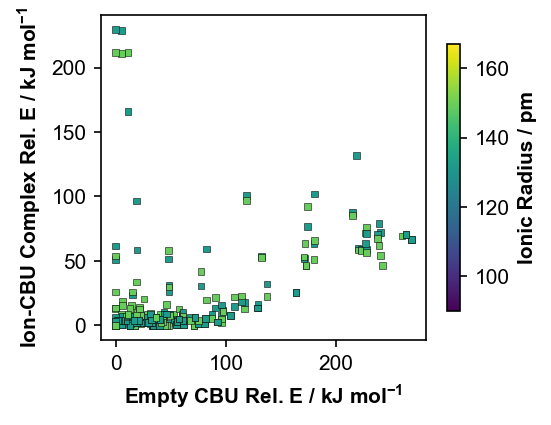

In [103]:
fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=150)

markers = {
    "divalent": "s",
}

for valence in markers.keys():
    ion_df = al_dist_comp_df[al_dist_comp_df["ion_valence"] == valence]
    im = ax.scatter(
        ion_df["rel_sol_empty_energy"],
        ion_df["rel_sol_dock_energy"],
        c=ion_df["bare_ion_radius"],
        cmap="viridis",
        norm=radnorm,
        label=valence,
        marker=markers[valence],
        s=10,
        edgecolors="k",
        linewidth=0.25,
    )

ax.set_xlabel("Empty CBU Rel. E / kJ mol$^{\mathdefault{-1}}$", fontweight="bold")
ax.set_ylabel("Ion-CBU Complex Rel. E / kJ mol$^{\mathdefault{-1}}$", fontweight="bold")

cbar = fig.colorbar(im, ax=ax, norm=norm, shrink=0.66)
cbar.set_label("Ionic Radius / pm", fontweight="bold")

ax.set_box_aspect(1)
# plt.legend(loc="upper left")
# ax.set_title("Rel. E for Al arrangement w/ vs. w/o Ion", fontweight="bold")

fig.savefig("figures/empty_vs_docked_rel_energies.svg", dpi=300)

# Assess all-solvent BEs

The above cells look at the following binding energy calculations:
- ion(vac) + CBU(vac) &rarr; complex(vac)
- ion(sol) + CBU(vac) &rarr; complex(vac)

I also want to check the following to see how closely it agrees with those BEs:
- ion(sol) + CBU(sol) &rarr; complex(sol)

Then, I will try to assess binding energies of these ions with explicit solvent if that isn't too difficult.

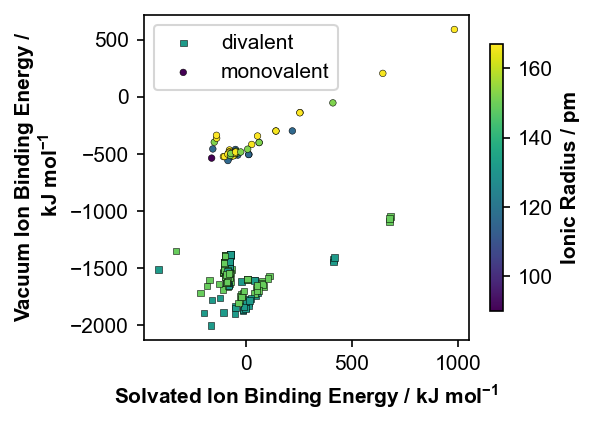

In [104]:
fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=150)

markers = {
    "divalent": "s",
    "monovalent": "o",
}

for valence in markers.keys():
    ion_df = df[df["ion_valence"] == valence]
    im = ax.scatter(
        ion_df["sol_sol_ion_binding_energy"],
        ion_df["ion_binding_energy"],
        c=ion_df["bare_ion_radius"],
        cmap="viridis",
        norm=radnorm,
        label=valence,
        marker=markers[valence],
        s=10,
        edgecolors="k",
        linewidth=0.25,
    )

ax.set_xlabel(
    "Solvated Ion Binding Energy / kJ mol$^{\mathdefault{-1}}$", fontweight="bold"
)
ax.set_ylabel(
    "Vacuum Ion Binding Energy /\n kJ mol$^{\mathdefault{-1}}$", fontweight="bold"
)

cbar = fig.colorbar(im, ax=ax, norm=norm, shrink=0.66)
cbar.set_label("Ionic Radius / pm", fontweight="bold")

ax.set_box_aspect(1)
plt.legend(loc="upper left")

fig.savefig("figures/vacuum_vs_sol_binding_energies.svg", dpi=300)

In [105]:
df.columns

Index(['docked_cbu_energy', 'cbu_nickname', 'bare_ion_formula',
       'bare_ion_radius', 'ion_valence', 'empty_cbu_geom_id',
       'empty_cbu_energy', 'solvated_cbu_energy', 'bare_ion_energy',
       'solvated_ion_energy', 'solvated_dock_geom_id', 'solvated_dock_energy',
       'rel_vac_docked_energy', 'rel_sol_docked_energy', 'ion_binding_energy',
       'solvated_ion_binding_energy', 'bare_solvated_binding_diff',
       'sol_sol_ion_binding_energy'],
      dtype='object')

In [106]:
mono_df[["ion_binding_energy", "sol_sol_ion_binding_energy"]].describe()

,ion_binding_energy,sol_sol_ion_binding_energy
count,52.000000,52.000000
mean,-413.634611,11.659169
std,197.510129,198.621200
min,-560.094210,-156.351402
25%,-499.766478,-76.933352
50%,-486.499197,-50.446591
75%,-402.601524,13.267423
max,588.783414,984.855792


In [107]:
di_df[["ion_binding_energy", "sol_sol_ion_binding_energy"]].describe()

,ion_binding_energy,sol_sol_ion_binding_energy
count,233.000000,233.000000
mean,-1562.004228,-57.023937
std,135.691263,115.249361
min,-2005.032610,-413.087527
25%,-1629.103967,-95.119272
50%,-1545.757160,-81.386794
75%,-1501.310115,-73.715151
max,-1052.083054,682.729779


In [108]:
mono_ions = df[df["ion_valence"] == "monovalent"]
# get the correlation matrix for the monovalent ions with quantitative data
mono_ion_corr = (
    mono_ions[["ion_binding_energy", "solvated_ion_binding_energy"]].corr(
        method="pearson"
    )
    ** 2
)
mono_ion_corr.loc["ion_binding_energy", "solvated_ion_binding_energy"]

np.float64(0.9550133644376332)

In [109]:
di_ions = df[df["ion_valence"] == "divalent"]
# get the correlation matrix for the divalent ions with quantitative data
di_ion_corr = (
    di_ions[["ion_binding_energy", "solvated_ion_binding_energy"]].corr(
        method="pearson"
    )
    ** 2
)
di_ion_corr.loc["ion_binding_energy", "solvated_ion_binding_energy"]

np.float64(0.9187118143905255)

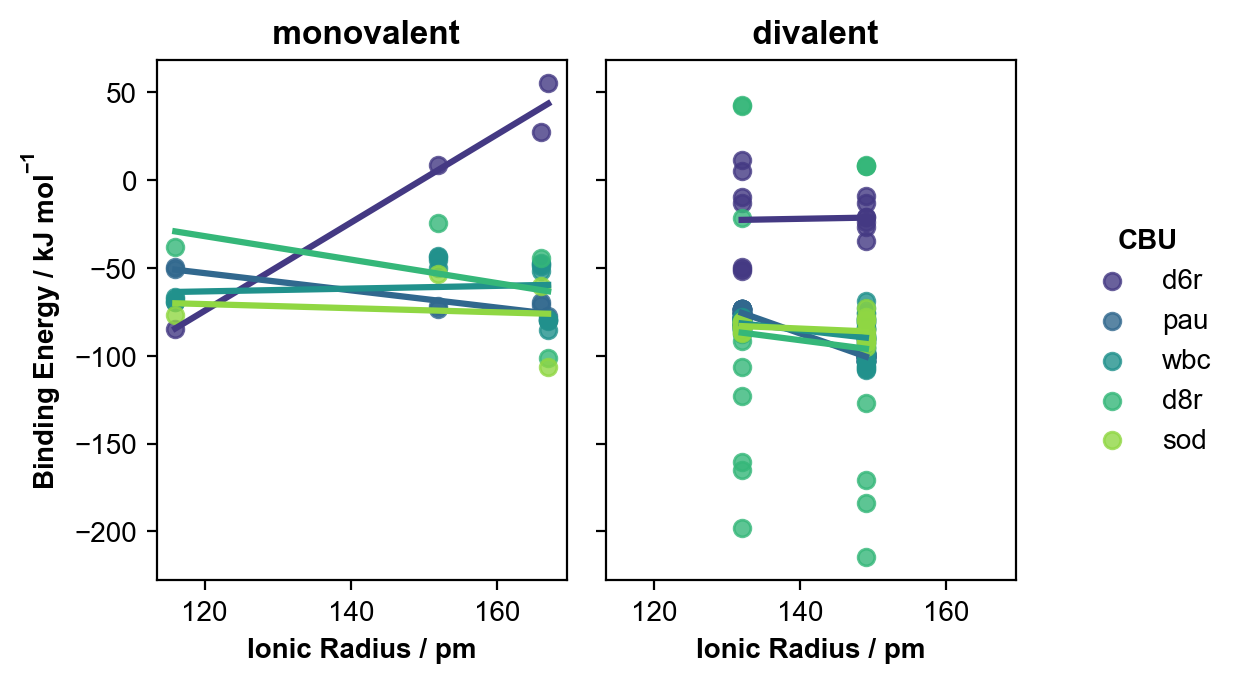

In [110]:
lm = sns.lmplot(
    data=df.loc[df["cbu_nickname"].isin(["d6r", "wbc", "pau", "sod", "d8r"])],
    x="bare_ion_radius",
    y="sol_sol_ion_binding_energy",
    hue="cbu_nickname",
    col="ion_valence",
    ci=None,
    palette="viridis",
    height=3.5,
    aspect=0.75,
)
axes = lm.axes
lm.set_xlabels("Ionic Radius / pm", fontweight="bold")
lm.set_ylabels("Binding Energy / kJ mol$\mathdefault{^{-1}}$", fontweight="bold")
lm.legend.set_title("CBU", prop={"weight": "bold"})
for ax in axes[0]:
    # set the axis title to the ion valence
    ax.set_title(ax.get_title().split("=")[1], fontweight="bold")
    # set the right and top spines to visible
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)

lm.savefig("figures/sol_binding_energies_f_radius.svg", dpi=300)

## Organize data for structure images

In [111]:
# get the rows from df in with the lowest sol_sol_ion_binding_energy for each cbu_nickname and bare_ion_formula

ions = df["bare_ion_formula"].unique()
cbus = df["cbu_nickname"].unique()

ion_cbu_pairs = [(ion, cbu) for ion in ions for cbu in cbus]

min_sol_binding_idx = []

for ion, cbu in ion_cbu_pairs:
    ion_cbu_df = df[(df["bare_ion_formula"] == ion) & (df["cbu_nickname"] == cbu)]
    try:
        min_sol_binding_idx.append(ion_cbu_df["rel_sol_docked_energy"].idxmin())
    except ValueError:
        print(f"No data for {ion} in {cbu}")

min_binding_df = df.loc[min_sol_binding_idx]

No data for Li+ in rth
No data for Li+ in d6r
No data for Li+ in pau
No data for Li+ in wbc
No data for Li+ in d8r
No data for Li+ in sod
No data for Li+ in d4r


In [112]:
min_binding_df["solvated_dock_geom_id"] = min_binding_df[
    "solvated_dock_geom_id"
].astype(int)

In [113]:
min_binding_df.to_csv("data/min_binding_energies.csv")